# Lab 2 - An A/B Test, End to End

*SDAIA Academy · Experimentation and Causal Inference · SOLUTION notebook*

## Objective
Plan an experiment with a real power calculation, verify the pipeline with an A/A test and a sample-ratio check, estimate the effect two ways (simple and CUPED-adjusted), check guardrails and segments with the right multiple-testing family, and show why peeking is not benign and how an always-valid boundary repairs it.

Dataset: `injaz_experiment_results.csv` - the randomized **guided uploader** test (80,000 users, hash-assigned 50/50). Columns: `user_id, variant, completed, pre_completion_rate, time_to_complete, support_ticket, upload_error, region, device, age, digital_literacy`.

In [1]:
import sys; sys.path.insert(0, '..')   # so `causal_utils` is importable from starter/ or solution/
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from causal_utils import *
plt.rcParams['figure.figsize'] = (7, 3.5)
rng = np.random.default_rng(213)
DATA = '../data'

In [2]:
df = pd.read_csv(f'{DATA}/injaz_experiment_results.csv')
print(df.shape); df.head()

(80000, 11)


,user_id,variant,completed,pre_completion_rate,time_to_complete,support_ticket,upload_error,region,device,age,digital_literacy
0,E000000,control,1,0.600,211.0,0,0,Madinah,ios,37,0.669
1,E000001,treatment,0,0.093,172.0,0,0,Asir,android,41,0.147
2,E000002,treatment,0,0.388,103.0,0,0,Makkah,android,67,0.383
3,E000003,treatment,0,0.244,134.0,0,0,Riyadh,web,69,0.238
4,E000004,treatment,0,0.497,101.0,0,0,Makkah,android,23,0.262


## Step 1 - Power, MDE and sample size
Baseline completion 0.55, MDE = +2 percentage points, alpha 0.05 two-sided, power 0.80. Cross-check the closed form against `statsmodels`. Then plot n vs MDE and produce the run-length plan (12,000 eligible users/day, trigger rate 0.6, 14-day floor).

n per arm: closed-form 9,666   statsmodels 9,669


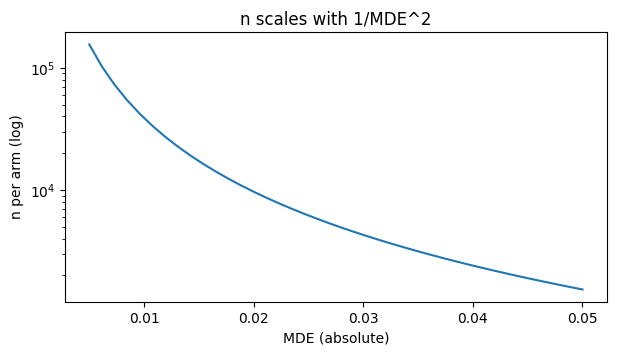

MDE detectable in 4 weeks at live traffic: 0.0062
Run length, 2 arms: 14 days
Run length, 3 arms: 14 days


In [3]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
p1, mde = 0.55, 0.02
n_closed = sample_size_proportions(p1, mde)
n_sm = NormalIndPower().solve_power(effect_size=proportion_effectsize(p1 + mde, p1), alpha=0.05, power=0.8)
print(f"n per arm: closed-form {n_closed:,}   statsmodels {int(np.ceil(n_sm)):,}")

mdes = np.linspace(0.005, 0.05, 40)
plt.plot(mdes, [sample_size_proportions(p1, m) for m in mdes]); plt.yscale('log')
plt.xlabel('MDE (absolute)'); plt.ylabel('n per arm (log)'); plt.title('n scales with 1/MDE^2'); plt.show()

print("MDE detectable in 4 weeks at live traffic:",
      round(mde_proportions(p1, n_per_arm=int(12_000 * 0.6 * 28 / 2)), 4))
for arms in (2, 3):
    print(f"Run length, {arms} arms: {run_length_days(n_closed, arms, 12_000, 0.6)} days")

## Step 2 - Integrity: reproduce the assignment, run the SRM check and the balance table
Re-derive the arm from the user_id with `assign_variant(uid, 'injaz-uploader-2026q2')`; it must match 100%. Then break the data on purpose (drop 3% of treatment rows) and confirm SRM flags it.

In [4]:
rederived = df['user_id'].map(lambda u: assign_variant(u, 'injaz-uploader-2026q2'))
print("Assignment reproducible:", (rederived == df['variant']).mean())
counts = df['variant'].value_counts().to_dict()
print("SRM clean :", srm_check(counts, {'control': .5, 'treatment': .5}))
broken = df.drop(df[df.variant == 'treatment'].sample(frac=0.03, random_state=1).index)
print("SRM broken:", srm_check(broken['variant'].value_counts().to_dict(), {'control': .5, 'treatment': .5}))
df['T'] = (df['variant'] == 'treatment').astype(int)
print(balance_table(df, ['age', 'digital_literacy', 'pre_completion_rate'], 'T'))

Assignment reproducible: 1.0
SRM clean : {'chi2': 1.037, 'p_value': 0.30856687686124606, 'srm_detected': False, 'verdict': 'ratios OK'}
SRM broken: {'chi2': 27.946, 'p_value': 1.247490464985614e-07, 'srm_detected': True, 'verdict': 'INVALID - investigate assignment/logging'}
             covariate     smd  balanced
0                  age -0.0036      True
1     digital_literacy  0.0015      True
2  pre_completion_rate -0.0006      True


## Step 3 - A/A test on simulated traffic
Simulate a data-generating process with a pre-period covariate correlated with the outcome, assign two arms with **no** effect, and confirm the pipeline returns a null result and a clean ratio. Repeat 500 times: the false-positive rate must be about 5%.

In [5]:
def simulate_traffic(n=20_000, effect=0.0, seed=0):
    r = np.random.default_rng(seed)
    pre = np.clip(r.normal(0.55, 0.15, n), 0, 1)
    t = r.binomial(1, 0.5, n)
    p = np.clip(0.12 + 0.75 * pre + effect * t, 0.01, 0.99)
    return pd.DataFrame({'T': t, 'pre': pre, 'y': r.binomial(1, p)})

aa = simulate_traffic(seed=42)
print("A/A estimate:", {k: round(v, 4) for k, v in diff_in_means(aa['y'].values, aa['T'].values).items()})
fp = np.mean([diff_in_means(*(s := simulate_traffic(seed=i))[['y', 'T']].values.T)['p_value'] < 0.05 for i in range(500)])
print(f"A/A false-positive rate over 500 sims: {fp:.3f} (expect ~0.05)")

A/A estimate: {'estimate': -0.0044, 'se': 0.0071, 'ci_low': -0.0182, 'ci_high': 0.0095, 'p_value': 0.5363}


A/A false-positive rate over 500 sims: 0.048 (expect ~0.05)


## Step 4 - Estimate the uploader effect two ways: simple difference vs CUPED-adjusted
Run (a) a two-proportion test, (b) OLS with HC3 robust SEs, (c) OLS with `pre_completion_rate` as a covariate, and (d) explicit CUPED on the outcome. Compare the standard errors and the variance reduction.

In [6]:
from statsmodels.stats.proportion import proportions_ztest
succ = df.groupby('T')['completed'].sum(); nobs = df.groupby('T').size()
z, p = proportions_ztest([succ[1], succ[0]], [nobs[1], nobs[0]])
simple = diff_in_means(df['completed'].values, df['T'].values)
print(f"Two-proportion: lift={simple['estimate']:+.4f} SE={simple['se']:.4f} p={p:.4f}")
m_robust = smf.ols('completed ~ T', data=df).fit(cov_type='HC3')
m_adj = smf.ols('completed ~ T + pre_completion_rate', data=df).fit(cov_type='HC3')
for name, m in [('OLS HC3', m_robust), ('OLS + pre covariate', m_adj)]:
    lo, hi = m.conf_int().loc['T']
    print(f"{name:20s} lift={m.params['T']:+.4f} SE={m.bse['T']:.4f} CI=[{lo:+.4f}, {hi:+.4f}]")
df['completed_cuped'] = cuped_adjust(df['completed'], df['pre_completion_rate'])
cu = diff_in_means(df['completed_cuped'].values, df['T'].values)
vr = 1 - df['completed_cuped'].var() / df['completed'].var()
print(f"CUPED                lift={cu['estimate']:+.4f} SE={cu['se']:.4f}  variance reduced {vr:.1%}  -> n multiplier {1-vr:.2f}")

Two-proportion: lift=+0.0223 SE=0.0035 p=0.0000
OLS HC3              lift=+0.0223 SE=0.0035 CI=[+0.0154, +0.0293]
OLS + pre covariate  lift=+0.0224 SE=0.0033 CI=[+0.0160, +0.0289]
CUPED                lift=+0.0224 SE=0.0033  variance reduced 13.3%  -> n multiplier 0.87


## Step 5 - Guardrails (Bonferroni) and a segment sweep (Benjamini-Hochberg)
Guardrails: `time_to_complete` (log scale), `support_ticket`, `upload_error`. A guardrail family uses FWER control. The exploratory region x device sweep uses FDR control; survivors are hypotheses for the next test, not findings.

In [7]:
from statsmodels.stats.multitest import multipletests
df['log_ttc'] = np.log(df['time_to_complete'])
guard = {}
for g in ['log_ttc', 'support_ticket', 'upload_error']:
    m = smf.ols(f'{g} ~ T', data=df).fit(cov_type='HC3')
    guard[g] = (m.params['T'], m.pvalues['T'])
rej, p_adj, _, _ = multipletests([v[1] for v in guard.values()], alpha=0.05, method='bonferroni')
for (g, (est, p)), pa, r in zip(guard.items(), p_adj, rej):
    print(f"guardrail {g:15s} effect={est:+.4f} raw p={p:.4f} bonf p={pa:.4f} -> {'REGRESSION?' if (r and est>0) else 'OK'}")

seg = []
for (reg, dev), sub in df.groupby(['region', 'device']):
    if sub['T'].nunique() == 2 and len(sub) > 500:
        r = diff_in_means(sub['completed'].values, sub['T'].values)
        seg.append({'segment': f'{reg}/{dev}', 'lift': r['estimate'], 'p': r['p_value']})
seg = pd.DataFrame(seg)
seg['p_bh'] = multipletests(seg['p'], method='fdr_bh')[1]
seg['raw_sig'] = seg['p'] < 0.05; seg['bh_sig'] = seg['p_bh'] < 0.05
print(f"{len(seg)} segments: {seg['raw_sig'].sum()} raw-significant, {seg['bh_sig'].sum()} survive BH")
seg.sort_values('p').head(8)

guardrail log_ttc         effect=+0.0034 raw p=0.1759 bonf p=0.5278 -> OK
guardrail support_ticket  effect=+0.0004 raw p=0.7560 bonf p=1.0000 -> OK
guardrail upload_error    effect=-0.0039 raw p=0.0189 bonf p=0.0566 -> OK


31 segments: 6 raw-significant, 1 survive BH


,segment,lift,p,p_bh,raw_sig,bh_sig
28,Riyadh/web,0.057681,0.001570,0.048685,True,True
26,Riyadh/android,0.024823,0.009105,0.099080,True,False
23,Qassim/android,0.054509,0.009588,0.099080,True,False
6,Eastern/android,0.029066,0.018741,0.132724,True,False
29,Tabuk/android,0.064413,0.021407,0.132724,True,False
12,Jazan/ios,0.063477,0.026992,0.139461,True,False
13,Jazan/web,0.080370,0.051549,0.222128,False,False
18,Makkah/ios,0.025363,0.063658,0.222128,False,False


## Step 6 - Peeking: 1,000 experiments with daily looks under the null
Stop at the first p < 0.05. Measure the realised false-positive rate for 1, 5, 10 and 20 looks.

In [8]:
def peeking_fpr(n_looks, per_look=500, n_sims=1000, alpha=0.05, seed=4):
    r = np.random.default_rng(seed); fp = 0
    for _ in range(n_sims):
        a = b = np.empty(0); hit = False
        for _ in range(n_looks):
            a = np.concatenate([a, r.normal(0, 1, per_look)]); b = np.concatenate([b, r.normal(0, 1, per_look)])
            if stats.ttest_ind(a, b).pvalue < alpha:
                hit = True; break
        fp += hit
    return fp / n_sims

for looks in (1, 5, 10, 20):
    print(f"{looks:2d} looks -> false-positive rate {peeking_fpr(looks):.1%}")

 1 looks -> false-positive rate 4.7%


 5 looks -> false-positive rate 13.4%


10 looks -> false-positive rate 19.6%


20 looks -> false-positive rate 25.5%


## Step 7 - Repeat under an always-valid boundary (mSPRT)
`msprt_reject(diff, var_diff)` returns True when the mixture likelihood ratio crosses 1/alpha. It may be checked at every look. The error rate should return to (below) nominal, and it still lets you stop early when a real effect exists.

In [9]:
def msprt_fpr(n_looks, per_look=500, n_sims=1000, effect=0.0, seed=5):
    r = np.random.default_rng(seed); hits = 0
    for _ in range(n_sims):
        a = b = np.empty(0); hit = False
        for _ in range(n_looks):
            a = np.concatenate([a, r.normal(effect, 1, per_look)]); b = np.concatenate([b, r.normal(0, 1, per_look)])
            diff = a.mean() - b.mean(); var = a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b)
            if msprt_reject(diff, var, tau2=0.05**2):
                hit = True; break
        hits += hit
    return hits / n_sims

print(f"mSPRT, 20 looks, no effect : rejection rate {msprt_fpr(20):.1%}  (<= 5%)")
print(f"mSPRT, 20 looks, effect 0.1: power {msprt_fpr(20, effect=0.1):.1%}")

mSPRT, 20 looks, no effect : rejection rate 1.4%  (<= 5%)
mSPRT, 20 looks, effect 0.1: power 100.0%


## Step 8 - Decision paragraph
Write four sentences: the lift and its CI, the guardrail verdict, whether the lift is *practically* significant against the 2-point MDE, and the one-line peeking rule this lab justifies.

*Your answer:*

...

### Fast finishers
Analyse `completed` at a fake session level (duplicate each user 3 times with correlated noise) with and without `cov_type='cluster'`. Watch the naive CI become dishonestly narrow.